In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA


sns.set(style="whitegrid")


df = pd.read_csv("Indian-Accident-Dataset.csv")
df.head(10)

,Type,Region,Male(0-14),Female(0-14),Male(14-18),Female(14-18),Male(18-30),Female(18-30),Male(30-45),Female(30-45),Male(45-60),Female(45-60),Male(60+),Female(60+)
0,State,Andhra Pradesh,299,157,582,105,3268,437,4622,687,3324,662,1422,479
1,State,Arunachal Pradesh,10,6,7,5,148,19,135,16,35,3,5,2
2,State,Assam,103,43,259,84,1234,250,1357,268,601,134,152,39
3,State,Bihar,1113,444,1816,543,3777,1059,2679,922,1668,477,741,166
4,State,Chhattisgarh,738,470,674,321,3876,1067,4006,1005,2814,763,1277,511
5,State,Goa,5,3,6,2,153,15,161,19,115,15,76,26
6,State,Gujarat,380,215,751,205,4564,924,6472,984,4662,716,1746,432
7,State,Haryana,261,137,401,184,4155,720,4686,695,2807,315,915,215
8,State,Himachal Pradesh,54,38,68,25,599,96,840,127,706,102,275,73
9,State,Jharkhand,137,45,851,148,1875,332,1770,342,1033,285,402,148


In [3]:
print(df.dtypes)

Type             object
Region           object
Male(0-14)        int64
Female(0-14)      int64
Male(14-18)       int64
Female(14-18)     int64
Male(18-30)       int64
Female(18-30)     int64
Male(30-45)       int64
Female(30-45)     int64
Male(45-60)       int64
Female(45-60)     int64
Male(60+)         int64
Female(60+)       int64
dtype: object


In [4]:

print(df.isna().sum())


df_missing = df.copy()
df_missing.loc[0:5, 'Male(18-30)'] = np.nan



df_missing['Male(18-30)'].fillna(df_missing['Male(18-30)'].median(), inplace=True)
print("Missing values after imputation:", df_missing['Male(18-30)'].isna().sum())

Type             0
Region           0
Male(0-14)       0
Female(0-14)     0
Male(14-18)      0
Female(14-18)    0
Male(18-30)      0
Female(18-30)    0
Male(30-45)      0
Female(30-45)    0
Male(45-60)      0
Female(45-60)    0
Male(60+)        0
Female(60+)      0
dtype: int64
Missing values after imputation: 0


/tmp/ipython-input-339/3031271641.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_missing['Male(18-30)'].fillna(df_missing['Male(18-30)'].median(), inplace=True)


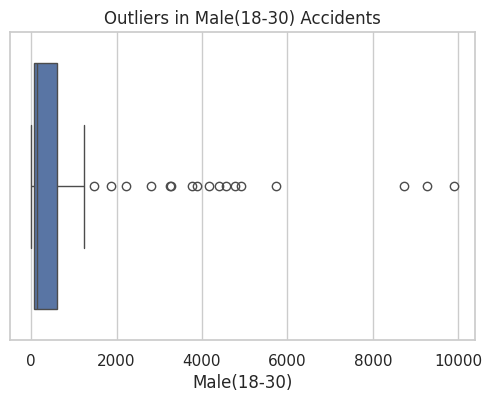

Original shape: (89, 14)
Shape after removing outliers: (72, 14)


In [5]:

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Male(18-30)'])
plt.title("Outliers in Male(18-30) Accidents")
plt.show()


Q1 = df['Male(18-30)'].quantile(0.25)
Q3 = df['Male(18-30)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


df_no_outliers = df[(df['Male(18-30)'] >= lower) & (df['Male(18-30)'] <= upper)]
print("Original shape:", df.shape)
print("Shape after removing outliers:", df_no_outliers.shape)

In [6]:

numeric_cols = df.select_dtypes(include=[np.number]).columns


scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])


scaler_zscore = StandardScaler()
df_zscore = df.copy()
df_zscore[numeric_cols] = scaler_zscore.fit_transform(df[numeric_cols])

df_zscore.head()

,Type,Region,Male(0-14),Female(0-14),Male(14-18),Female(14-18),Male(18-30),Female(18-30),Male(30-45),Female(30-45),Male(45-60),Female(45-60),Male(60+),Female(60+)
0,State,Andhra Pradesh,0.573090,0.536572,0.703447,0.259175,1.081204,0.454976,1.259788,0.840713,1.225079,1.207461,0.960686,1.032612
1,State,Arunachal Pradesh,-0.383399,-0.367514,-0.423596,-0.393715,-0.438088,-0.421520,-0.449400,-0.451638,-0.479559,-0.474736,-0.457294,-0.426400
2,State,Assam,-0.075601,-0.145983,0.070342,0.122068,0.090743,0.062859,0.016084,0.033716,-0.186210,-0.140338,-0.310192,-0.313227
3,State,Bihar,3.267147,2.254936,3.122180,3.118832,1.329063,1.759237,0.519660,1.293324,0.366800,0.735221,0.279215,0.075231
4,State,Chhattisgarh,2.026028,2.410606,0.883774,1.669417,1.377271,1.776012,1.025141,1.453183,0.960754,1.465279,0.815586,1.130491


Explained Variance Ratio: [0.8751315  0.08002794]


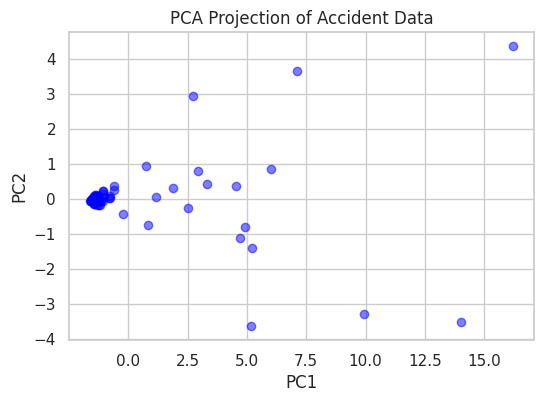

In [7]:

pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_zscore[numeric_cols])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1], color='blue', alpha=0.5)
plt.title("PCA Projection of Accident Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()